# Outline

Linear regression model implementation without libraries.

- Implementing linear regression model $f_{w,b} (x) = wx + b$
- Implementing squared error cost function $J(w,b) = \frac{1}{2m} \cdot \sum\limits_{i=1}^{m}(f_{w,b} (x^{(i)}) - y^{(i)})^{2}$
- Implementing gradient function
- Implementing gradient descent $w = w - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)}) \cdot x^{(i)}$
	,
	$b = b - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)})$

## Packages 

- [numpy](www.numpy.org) - working with matrices in Python.
- [matplotlib](http://matplotlib.org) - plot graphs in Python.


## Dataset

A lot of datasets related to diabetes are not made for linear regression (continuous values), but are instead made for logistic regression models (binary classification).

I will be using diabetes dataset from [Kaggle](https://www.kaggle.com/code/azratuni/diabetes-database-linear-regression/input). I will be using insulin as the input feature and glucose as the target.

## Notes

*Terminology*: 
- Data used to train the model is called a *training set*.

*Notation*: 
- *x* = "input" variable or feature
- *y* = "output" variable or "target" variable
- *m* = number of training examples
- *(x, y)* = single training example
- $(x^{(i)}, y^{(i)})$ = $i^{th}$ (index) training example ($1^{st},$ $2^{nd}$, $3^{rd}$, ...). Ex: $(x^{(1)}, y^{(1)})$ = $(2104, 400)$. 
	- Value $2104$ is x's first training example while value $400$ is y's first training example.

*Training set* = Input features and output targets

Linear regression model:

$f_{w,b} (x) = wx + b$

A *cost function* is used to measure just how wrong the model is in finding a relation between the input and the output. The cost function tells the model how to improve. Without it, the model wouldn’t know whether it’s getting better or worse.

*`Cost function`*: Compare the prediction $\hat{y}$ to the target $y$.

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example 
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
    * The cost for that example  $$cost^{(i)} =  (f_{wb} - y^{(i)})^2$$
    

* Return the total cost over all examples
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator
- $J(w,b) = \frac{1}{2m} \cdot \sum\limits_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^{2}$ 
- This is the *squared error cost function*. It is the most common cost function in linear regression.
- This can be rewritten as $J(w,b) = \frac{1}{2m} \cdot \sum\limits_{i=1}^{m}(f_{w,b} (x^{(i)}) - y^{(i)})^{2}$ 

- The goal in this instance: find the value of $w$ that minimizes $J(w,b)$.
- General case: Find the values of $w$ and $b$ that minimize $J$.

When the cost is relatively small, closer to zero, it means the model fits the data better compared to other choices for $w$ and $b$.

*`Gradient function`*:

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example 
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
    * The gradient for the parameters $w, b$ from that example 
        $$
        \frac{\partial J(w,b)}{\partial b}^{(i)}  =  (f_{w,b}(x^{(i)}) - y^{(i)}) 
        $$
        $$
        \frac{\partial J(w,b)}{\partial w}^{(i)}  =  (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} 
        $$
    

* Return the total gradient update from all the examples
    $$
    \frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial b}^{(i)}
    $$
    
    $$
    \frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial w}^{(i)} 
    $$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator

We have some function $J(w,b)$ that we want to minimize. This is a cost function for linear regression, but we can use gradient descent algorithm to try to minimize any function, not just a cost function for linear regression.

Say we have $J(w_1, w_2, ..., w_n, b)$, our objective is to minimize $J$ over the parameters $w_1, ..., w_n$ and $b$. We want to pick values for $w_1$ through $w_n$ and $b$, that it gives us the smallest possible value of $J$.

*`Gradient Descent Algorithm`*:

Now you repeat until convergence:
	$w = w - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)}) \cdot x^{(i)}$
	,
	$b = b - \alpha \cdot \frac{1}{m} \cdot \sum\limits_{i=1}^{m} (f_{w,b} (x^{(i)}) - y^{(i)})$


## Linear Regression Model implementation

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [[  1.   0.]
 [  1.   0.]
 [  1.   0.]
 [  1.  94.]
 [  1. 168.]]
Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [148  85 183  89 137]
Final w: 0.5090402257881949, Final b: 10.946817057564983


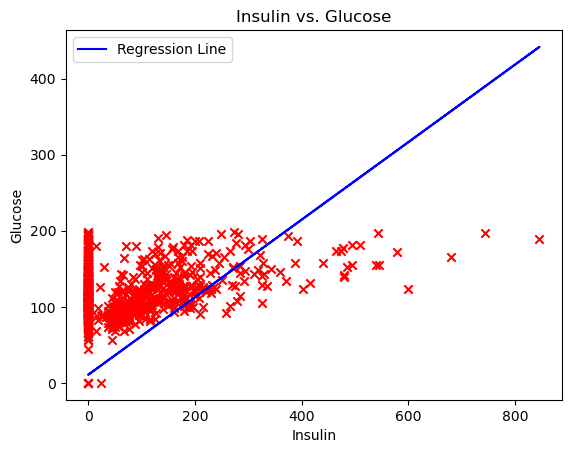

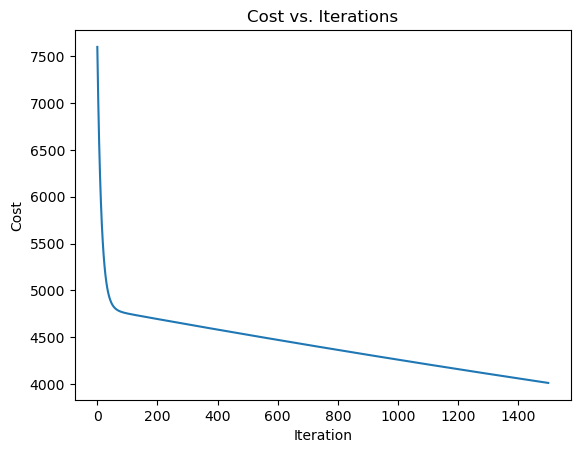

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

class LinearRegression:
    def __init__(self, learning_rate_alpha, n_iterations):
        self.learning_rate_alpha = learning_rate_alpha
        self.n_iterations = n_iterations
        self.w = 0
        self.b = 0

    def compute_cost(self, x, y, w, b):
        m = x.shape[0]
        cost_sum = 0
        for i in range(m):
            f_wb = w * x[i, 1] + b
            cost = (f_wb - y[i]) ** 2
            cost_sum += cost
        total_cost = (1/(2*m)) * cost_sum
        return total_cost
    
    def compute_gradient(self, x, y, w, b):
        m = x.shape[0]
        dj_dw = 0
        dj_db = 0
        for i in range(m):
            f_wb = w * x[i, 1] + b
            dj_db += (f_wb - y[i])
            dj_dw += ((f_wb - y[i]) * x[i, 1])
        dj_db /= m
        dj_dw /= m
        return dj_dw, dj_db
    
    def gradient_descent(self, x, y, w_in, b_in):
        w = copy.deepcopy(w_in)
        b = b_in
        cost_history = []

        for i in range(self.n_iterations):
            dj_dw, dj_db = self.compute_gradient(x, y, w, b )
            w -=self.learning_rate_alpha * dj_dw
            b -= self.learning_rate_alpha * dj_db
            cost = self.compute_cost(x, y, w, b)
            cost_history.append(cost)

        return w, b, cost_history
        
def load_data(file_path):
    df = pd.read_csv(file_path)

    X = df["Insulin"].values # matrix
    y = df["Glucose"].values

    X = X.reshape(-1, 1) # reshapes 1D array into 2D array

    X = np.c_[np.ones(X.shape[0]), X] # add bias term

    '''
    with open(file_path, 'r') as file:
        for line in file:
            xi, yi = line.strip().split(',')
            x.append(float(xi))
            y.append(float(yi))
    return np.array(x), np.array(y)
    '''

    return X, y

if __name__ == "__main__":
    # load data
    X_train, y_train = load_data("diabetes.csv")

    # view data
    print("Type of x_train:",type(X_train))
    print("First five elements of x_train are:\n", X_train[:5])
    print("Type of y_train:",type(y_train))
    print("First five elements of y_train are:\n", y_train[:5])

    model = LinearRegression(0.0001, 1500)
    w_final, b_final, cost_history = model.gradient_descent(X_train, y_train, 0, 0)

    print(f"Final w: {w_final}, Final b: {b_final}")

    # plot data
    plt.scatter(X_train[:, 1], y_train, marker='x', c='r')
    plt.plot(X_train[:, 1], w_final * X_train[:, 1] + b_final, c='b', label="Regression Line")
    plt.title("Insulin vs. Glucose")
    plt.ylabel('Glucose')
    plt.xlabel('Insulin')
    plt.legend()
    plt.show()

    # Plot cost history
    plt.plot(cost_history)
    plt.title("Cost vs. Iterations")
    plt.ylabel('Cost')
    plt.xlabel('Iteration')
    plt.show()